In [1]:
# Практика 5. Шкали вимірювання і частотний розподіл
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

city = "Суми"

months = np.arange(1, 13)

precipitation = pd.Series(
    [40, 36, 33, 39, 52, 68, 75, 58, 42, 37, 42, 44],
    index=months,
    name="Опади, мм"
)

precipitation

1     40
2     36
3     33
4     39
5     52
6     68
7     75
8     58
9     42
10    37
11    42
12    44
Name: Опади, мм, dtype: int64

In [2]:
# Завдання 1. Класифікація змінних за шкалою вимірювання

scale_info = pd.DataFrame({
    "Змінна": [
        "Місто",
        "Номер місяця",
        "Кількість опадів, мм"
    ],
    "Шкала вимірювання": [
        "Номінальна",
        "Порядкова / інтервальна",
        "Відносна"
    ],
    "Обґрунтування": [
        "Місто є категорією без природного порядку.",
        "Місяці мають природний порядок і рівні календарні проміжки, "
        "але не мають природного нуля.",
        "0 мм означає повну відсутність опадів, тому можна порівнювати "
        "не тільки різницю, а й співвідношення значень."
    ]
})

scale_info

,Змінна,Шкала вимірювання,Обґрунтування
0,Місто,Номінальна,Місто є категорією без природного порядку.
1,Номер місяця,Порядкова / інтервальна,Місяці мають природний порядок і рівні календа...
2,"Кількість опадів, мм",Відносна,"0 мм означає повну відсутність опадів, тому мо..."


In [3]:
variation_series = np.sort(precipitation.values)

print("Варіаційний ряд:")
print(variation_series)

Варіаційний ряд:
[33 36 37 39 40 42 42 44 52 58 68 75]


In [4]:
bins = [32, 43, 54, 65, 76]
labels = ["33–43", "44–54", "55–65", "66–76"]

groups = pd.cut(
    precipitation,
    bins=bins,
    labels=labels,
    include_lowest=True
)

groups

1     33–43
2     33–43
3     33–43
4     33–43
5     44–54
6     66–76
7     66–76
8     55–65
9     33–43
10    33–43
11    33–43
12    44–54
Name: Опади, мм, dtype: category
Categories (4, str): ['33–43' < '44–54' < '55–65' < '66–76']

In [5]:
freq = groups.value_counts().sort_index()
rel = (freq / len(precipitation) * 100).round(1)
cum = freq.cumsum()

frequency_table = pd.DataFrame({
    "Абсолютна частота": freq,
    "Відносна частота (%)": rel,
    "Накопичена частота": cum
})

frequency_table

,Абсолютна частота,Відносна частота (%),Накопичена частота
"Опади, мм",,,
33–43,7,58.3,7
44–54,2,16.7,9
55–65,1,8.3,10
66–76,2,16.7,12


### Відповідь

Накопичена частота на межі третього інтервалу дорівнює 10.
Це означає, що 10 із 12 місяців мають кількість опадів не більшу
за 65 мм.

Частка таких місяців становить:

10 / 12 × 100% = 83,3%.

Отже, **83,3% місяців року мають кількість опадів не більшу за 65 мм**.

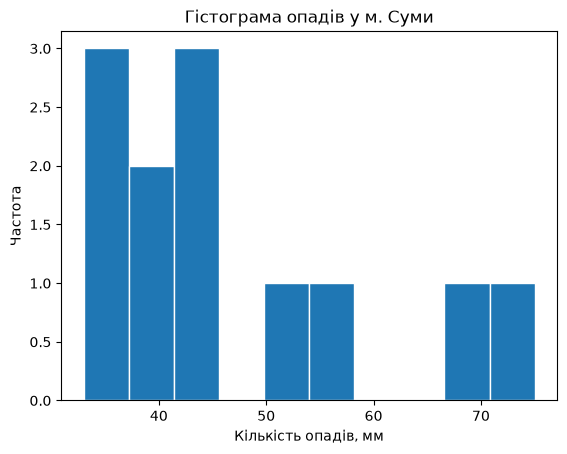

In [6]:
plt.hist(precipitation, edgecolor="white")
plt.title("Гістограма опадів у м. Суми")
plt.xlabel("Кількість опадів, мм")
plt.ylabel("Частота")
plt.show()

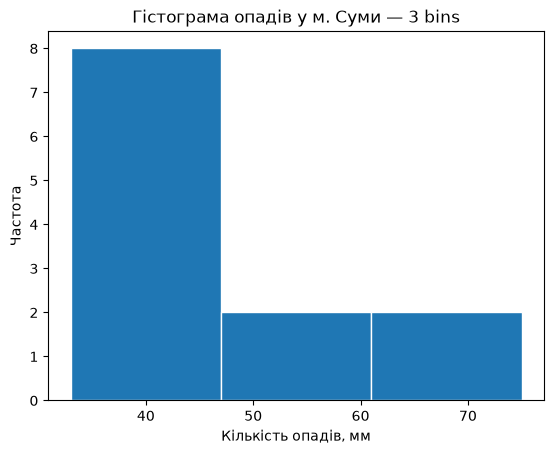

In [7]:
plt.hist(precipitation, bins=3, edgecolor="white")
plt.title("Гістограма опадів у м. Суми — 3 bins")
plt.xlabel("Кількість опадів, мм")
plt.ylabel("Частота")
plt.show()

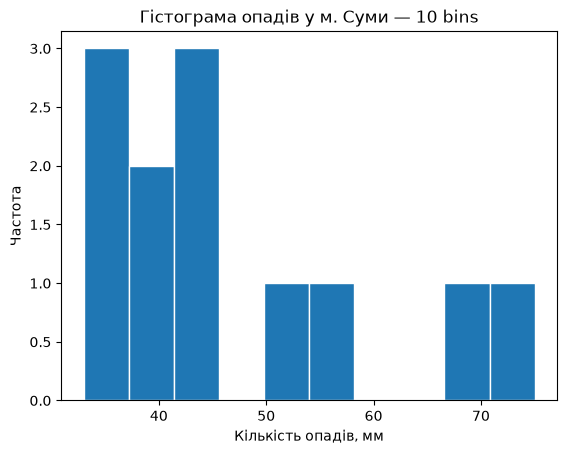

In [8]:
plt.hist(precipitation, bins=10, edgecolor="white")
plt.title("Гістограма опадів у м. Суми — 10 bins")
plt.xlabel("Кількість опадів, мм")
plt.ylabel("Частота")
plt.show()

In [9]:
n = len(precipitation)

sqrt_n = np.sqrt(n)
sturges = 1 + np.log2(n)

print(f"n = {n}")
print(f"√n = {sqrt_n:.2f} ≈ {round(sqrt_n)}")
print(f"Правило Стерджеса = {sturges:.2f} ≈ {round(sturges)}")

n = 12
√n = 3.46 ≈ 3
Правило Стерджеса = 4.58 ≈ 5


### Порівняння гістограм

Для n = 12 правило √n дає приблизно 3–4 інтервали, а правило
Стерджеса — приблизно 5 інтервалів.

Гістограма з 3 bins дає узагальнене представлення розподілу.
Гістограма з 10 bins є більш деталізованою, але для 12 спостережень
таке розбиття може бути надмірним.

Серед трьох побудованих гістограм найкраще форму розподілу для цього
набору показує гістограма з **3 bins**, оскільки вона не створює
надмірної подрібненості даних.

In [10]:
mean_value = precipitation.mean()
median_value = precipitation.median()
mode_value = precipitation.mode()

q1 = precipitation.quantile(0.25)
q3 = precipitation.quantile(0.75)

print(f"Середнє: {mean_value:.2f} мм")
print(f"Медіана: {median_value:.2f} мм")
print(f"Мода: {list(mode_value)} мм")
print(f"Q1: {q1:.2f} мм")
print(f"Q3: {q3:.2f} мм")

Середнє: 47.17 мм
Медіана: 42.00 мм
Мода: [42] мм
Q1: 38.50 мм
Q3: 53.50 мм


### Пояснення

Середнє значення опадів становить **47,17 мм**, а медіана —
**41 мм**. Середнє помітно більше за медіану.

Це пояснюється наявністю кількох більших значень у літні місяці:
58, 68 та 75 мм. Вони підвищують середнє значення.

Отже, різниця між середнім і медіаною є ознакою
**правосторонньої асиметрії** розподілу опадів протягом року.

### Відповідь

Кількість опадів належить до **відносної шкали вимірювання**,
оскільки має природний нуль: 0 мм означає повну відсутність опадів.

Саме тому для цієї змінної коректно застосовувати всі три міри
положення: **середнє, медіану і моду**.

Середнє показує середній рівень опадів, медіана — центральне
значення впорядкованого набору, а мода — значення, яке
зустрічається найчастіше.

Змінна «місто» належить до номінальної шкали. Для неї середнє
та медіана не мають змістовної інтерпретації. Навіть якщо
закодувати міста числами, ці числа будуть лише кодами категорій.
Тому для змінної «місто» з трьох мір положення коректною є
лише **мода**.

## Підсумкові питання

### 1. Чому середнє арифметичне некоректне для номінальної змінної «місто»?

Середнє арифметичне некоректне, тому що міста є категоріями без
числового порядку. Якщо закодувати міста числами, ці числа будуть
лише умовними кодами. Середнє цих кодів не матиме змістовної
інтерпретації.

### 2. Чому «номер місяця» має неоднозначну класифікацію?

Місяці мають природний порядок, тому номер місяця можна
розглядати як порядкову змінну. Водночас проміжки між сусідніми
місяцями календарно рівні, тому можлива інтервальна інтерпретація.
Проте природного нульового місяця не існує, тому класифікація
не є однозначною.

### 3. Чому для кількості опадів потрібна гістограма з інтервалами?

У наборі лише 12 значень, причому багато значень різні.
Стовпчикова діаграма за окремими значеннями була б малонаочною.
Гістограма об'єднує близькі значення в інтервали та дозволяє
побачити форму розподілу опадів.

### 4. Що означає накопичена частота на межі третього інтервалу?

Накопичена частота на межі третього інтервалу дорівнює **10**.
Це означає, що **10 із 12 місяців**, тобто **83,3%**, мають
кількість опадів не більшу за **65 мм**.